In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display charts inside the notebook
%matplotlib inline

# Load the cleaned dataset
df = pd.read_csv("../data/processed/cleaned_retail.csv")

# Check first 5 rows
df.head()

Matplotlib is building the font cache; this may take a moment.


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [2]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Shape: (400916, 9)

Columns:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue'],
      dtype='str')

Data Types:
Invoice          int64
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
Revenue        float64
dtype: object

Missing Values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64

Summary Statistics:


,Invoice,Quantity,Price,Customer ID,Revenue
count,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000
mean,514731.380771,13.767418,3.305826,15361.544074,21.945330
std,14090.603233,97.638385,35.047719,1680.635823,77.758075
min,489434.000000,1.000000,0.001000,12346.000000,0.001000
25%,502752.000000,2.000000,1.250000,13985.000000,5.000000
50%,515192.000000,5.000000,1.950000,15311.000000,12.500000
75%,527065.500000,12.000000,3.750000,16805.000000,19.500000
max,538171.000000,19152.000000,10953.500000,18287.000000,15818.400000


In [3]:
print("="*50)
print("BUSINESS KPIs")
print("="*50)

print("Total Revenue : ₹{:,.2f}".format(df["Revenue"].sum()))
print("Total Orders  :", df["Invoice"].nunique())
print("Total Customers:", df["Customer ID"].nunique())
print("Total Products :", df["StockCode"].nunique())
print("Total Countries:", df["Country"].nunique())

BUSINESS KPIs
Total Revenue : ₹8,798,233.74
Total Orders  : 19213
Total Customers: 4312
Total Products : 4017
Total Countries: 37


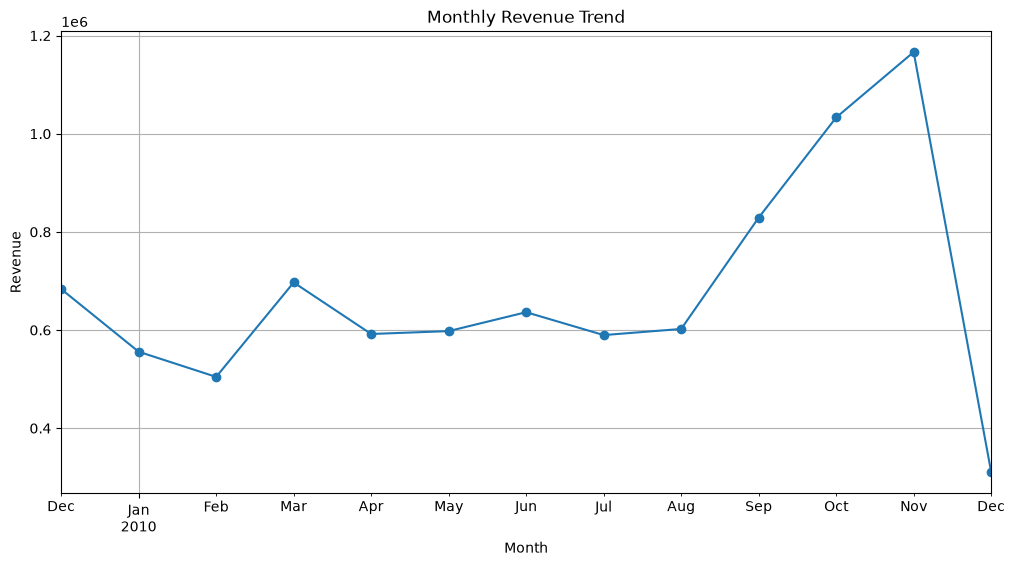

In [4]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create Year-Month column
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

# Monthly Revenue
monthly_sales = df.groupby("YearMonth")["Revenue"].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

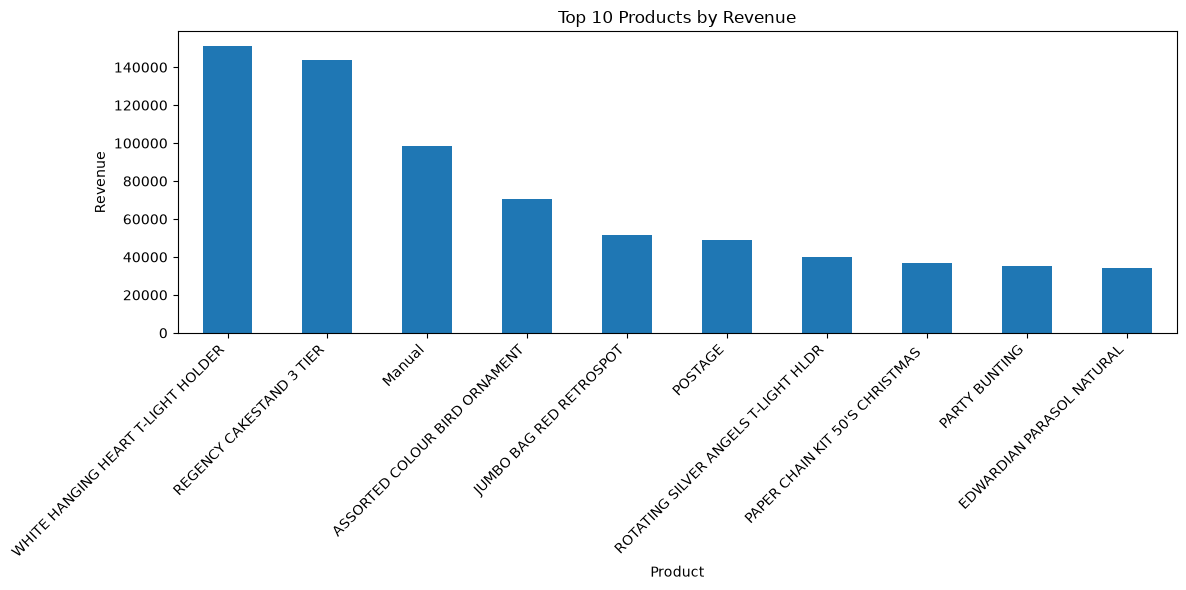

In [5]:
# Top 10 Products by Revenue

top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("../outputs/charts/top10_products.png", dpi=300)

plt.show()

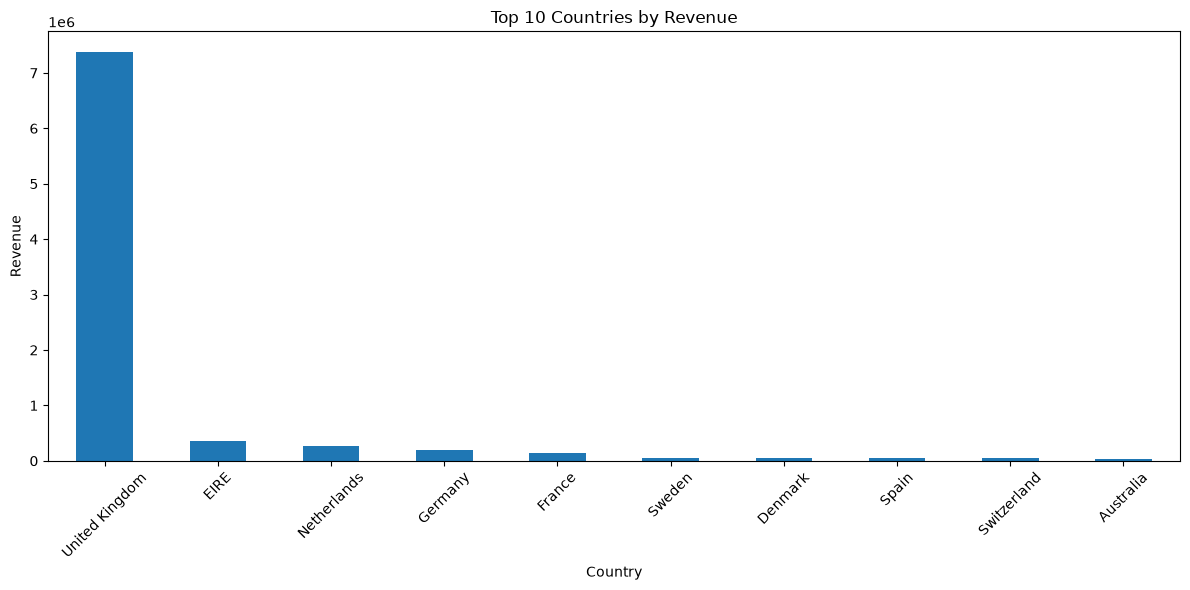

In [6]:
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
country_sales.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/top10_countries.png", dpi=300)

plt.show()

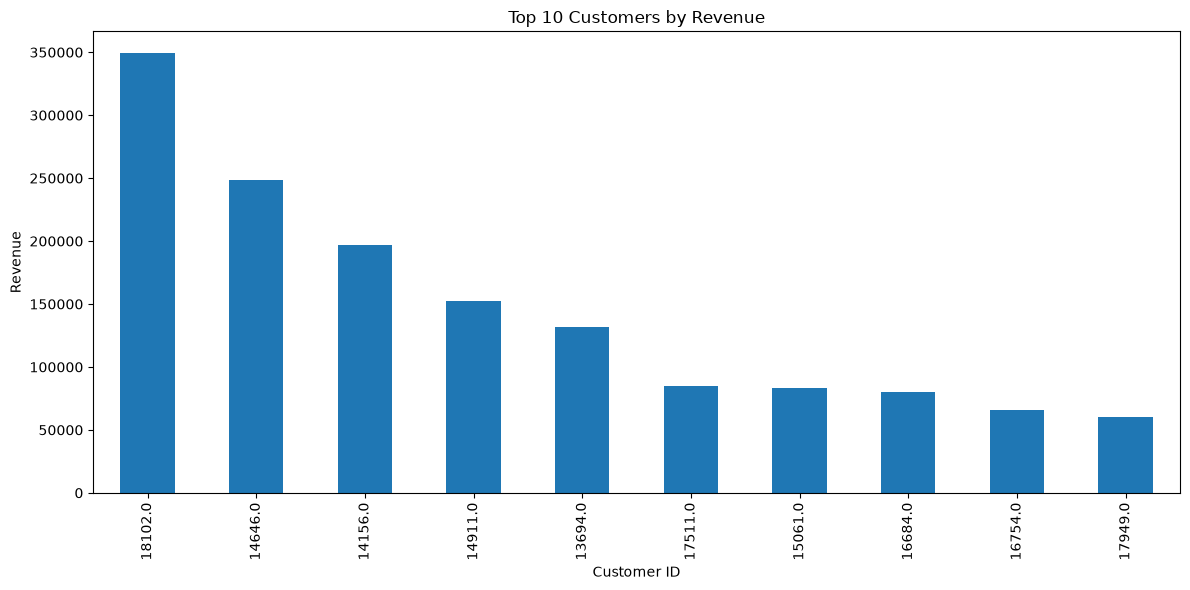

In [7]:
top_customers = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig("../outputs/charts/top10_customers.png", dpi=300)

plt.show()

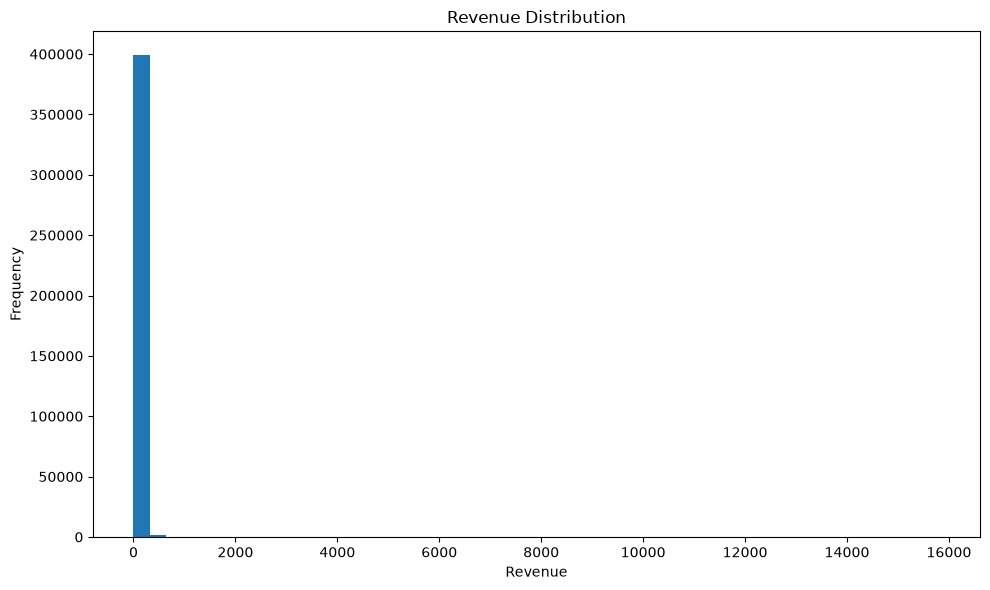

In [8]:
plt.figure(figsize=(10,6))

plt.hist(df["Revenue"], bins=50)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../outputs/charts/revenue_distribution.png", dpi=300)

plt.show()

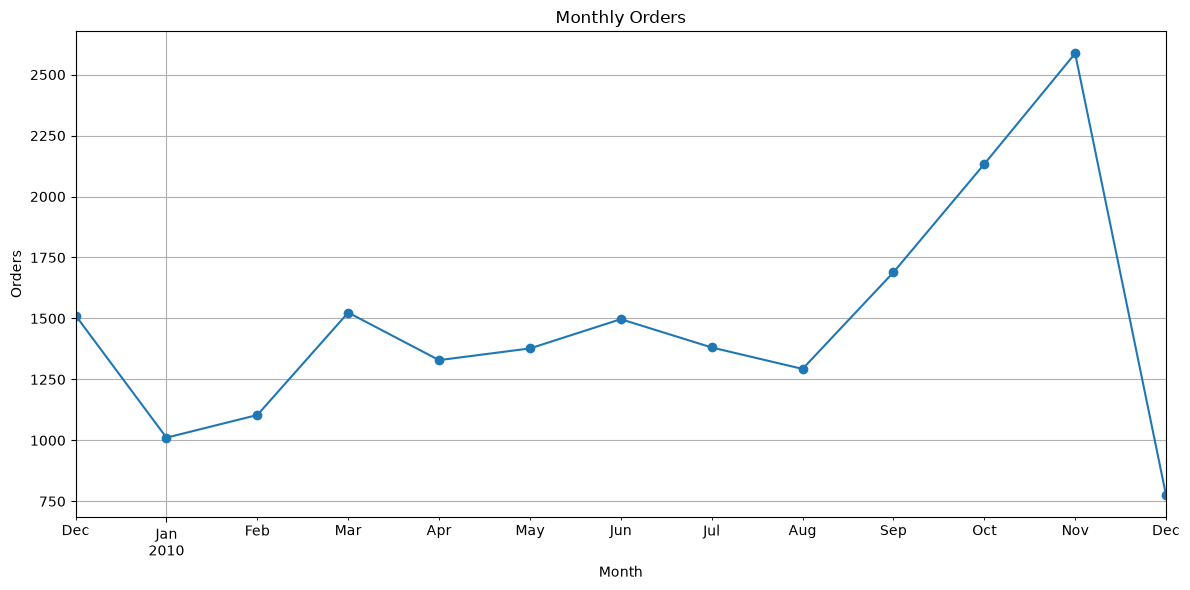

In [9]:
monthly_orders = (
    df.groupby("YearMonth")["Invoice"]
      .nunique()
)

plt.figure(figsize=(12,6))

monthly_orders.plot(marker="o")

plt.title("Monthly Orders")

plt.xlabel("Month")

plt.ylabel("Orders")

plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/charts/monthly_orders.png", dpi=300)

plt.show()

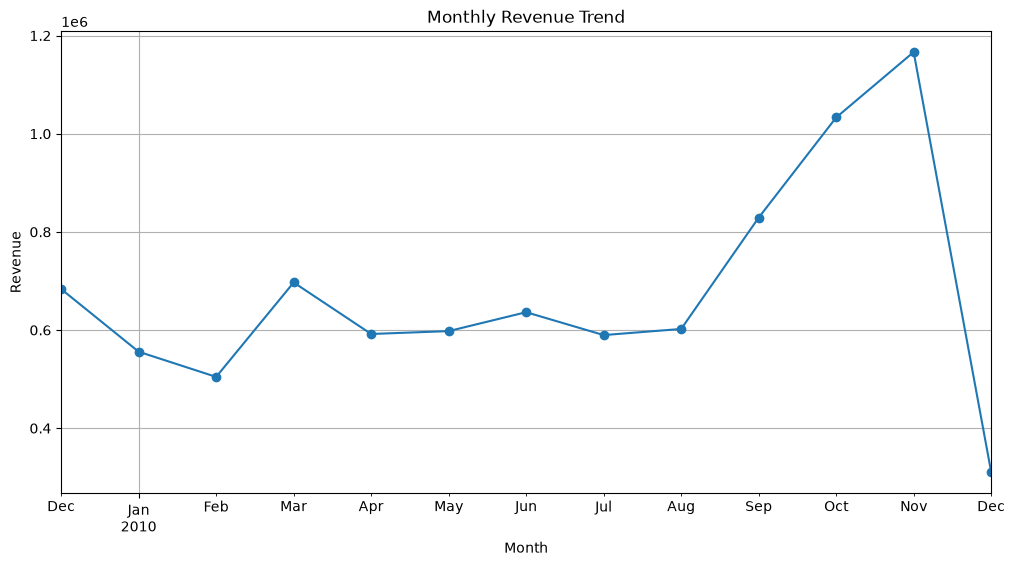

✅ Chart saved successfully!


In [10]:
import os
import matplotlib.pyplot as plt

# Create Year-Month column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

# Monthly Revenue
monthly_sales = df.groupby("YearMonth")["Revenue"].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

# Create folder if it doesn't exist
os.makedirs("../outputs/charts", exist_ok=True)

# Save the chart BEFORE plt.show()
plt.savefig("../outputs/charts/monthly_revenue_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

print("✅ Chart saved successfully!")

In [11]:
df = pd.read_csv("../data/processed/cleaned_retail.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,DayOfWeek,Quarter,Week,Weekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday,4,49,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,4,49,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,4,49,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,Tuesday,4,49,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,Tuesday,4,49,False


In [14]:
import sys
import os

# Add src folder to Python path
sys.path.append(os.path.abspath("../src"))

from rfm_segmentation import create_rfm

rfm = create_rfm(df)
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [15]:
# Daily Demand

daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)
      .agg({
          "Quantity": "sum",
          "Revenue": "sum"
      })
      .reset_index()
)

daily_sales.rename(columns={"InvoiceDate": "Date"}, inplace=True)

daily_sales.head()

,Date,Quantity,Revenue
0,2009-12-01,24335,43894.87
1,2009-12-02,29679,52762.06
2,2009-12-03,48009,67413.62
3,2009-12-04,19954,33913.81
4,2009-12-05,5119,9803.05


In [16]:
daily_sales.to_csv("../outputs/tables/daily_sales.csv", index=False)

print("Daily Sales Dataset Saved!")

Daily Sales Dataset Saved!
